Required python libraries

In [296]:
import scipy as scp
import sympy as sp
import control as ct
import matplotlib.pyplot as plt
import numpy as np

---

# **PreShape Filter Analysis**

**Objective**

Study the analog PreShape circuit used in the custom fuzz pedal and understand how it modifies the guitar spectrum before the saturation stages (transistor-based and diode-based).

This notebook contains:

- theoretical analysis
- symbolic derivations
- numerical simulations
- engineering interpretation
---

# **I. Presentation**
In this notebook, we will go through the first stage of the pedal called *PreShape*. It is basically a **band-pass filter** with a fixed low-pass filter, to cut some unwanted high-end, combined with a variable high-pass filter. Since clipping stages are highly dependent on the input spectrum, this stage has a major influence on the overall character of the distortion. Even if I am not sure about how they did it, this could be seen as a simplified version of Kernom's Pretone control on the Moho pedal.  
  
Here we will try to answer this simple question :  
* How does the *PreShape* circuit alter the spectral content of the guitar signal before nonlinear clipping, and why does this change the perceived character of the fuzz?
---

# **II. Theoretical background**

---
### Design assumptions

For this first-order analysis we assume:

- ideal passive components
- infinite transistor input impedance
- linear operating region
- negligible parasitic capacitances
- Laplace notation : $j\omega = s$
---

## 1. Circuit overview  
  
The whole fuzz circuit looks like this :  
  
![title](img/Fuzz_variableHPF.png)  
  
Before doing any physical analysis, let's take a closer look at the actual *Preshape* circuit's schematic :  
  
![title](img/Preshape.png)  
  
Here we can clearly see that the circuit consists of two main parts, two filters : an HPF and a LPF.

## 2. Variable high-pass filter analysis
Let's take a closer look at the variable HPF :  
  
![title](img/Variable_HPF.png)

In [297]:
s = sp.symbols('s') # Laplace parameter
R, C = sp.symbols('R C', positive=True)
Zc = 1/(C*s) # Capacitor impedance
Zr = R # Resistor impedance

In [298]:
H_hp = (Zr)/(Zc + Zr) #Transfer function using voltage divider
H_hp

R/(R + 1/(C*s))

In [299]:
H_hp = sp.simplify(H_hp)
H_hp

C*R*s/(C*R*s + 1)

In [300]:
N, D = sp.fraction(H_hp)
N

C*R*s

In [301]:
D

C*R*s + 1

The cutoff frequency is directly linked to the pole location

In [302]:
zeros = sp.solve(N,s)
poles = sp.solve(D,s)
poles[0]

-1/(C*R)

In [303]:
zeros

[0]

The filter gives a first-order response with only one real pole.

Then we should chose numerical values for R and C to study the physical behavior of our system :

In [304]:
values = {
    R: 10e3,
    C: 47e-9
}

H_num = sp.simplify(H_hp.subs(values))
H_num

0.00047*s/(0.00047*s + 1)

---
Here we will just define two handy function to use throughout the notebook

In [305]:
def sympy_to_tf(H, r : float, c :float):
    """
    This function converts sympy equation with numerical coef to ct transfer function

    Parameters:
        H : sympy object
        r : float resistance value
        c : float capacity value

    Returns:
        sys : ct transfer function
    """
    values = {
    R: r,
    C: c
    }

    H_num = sp.simplify(H.subs(values))
    num, den = sp.fraction(H_num)
    N_poly = sp.Poly(num, s)
    D_poly = sp.Poly(den, s)
    N_coeffs = N_poly.all_coeffs()
    D_coeffs = D_poly.all_coeffs()
    N_coeffs = [float(c) for c in N_coeffs]
    D_coeffs = [float(c) for c in D_coeffs]
    sys = ct.TransferFunction(
        N_coeffs,
        D_coeffs
    )
    return sys

In [306]:
def Variable_resistance_bode(H, R_values : list, C_value : float, frequency_range : tuple, n : int, title : str, save : bool = False):
    """
        This function creates Bode diagram for each resistance values in R_values for a given capacity
        and through the frequency range indicated by frequency_range

    Parameters:
        H : the transfer function to study
        R_values : list of resistance values to test in Ω
        C_value : float, the capacitor capacity in F
        frequency_range : tuple like (lowest, highest) in Hertz
        n : int, number of calculation nodes
        title : str, name of the plot

    Returns:
        void
    """
    low = min(frequency_range[0], frequency_range[1])
    high = max(frequency_range[0], frequency_range[1])
    f = np.logspace(np.log10(low), np.log10(high), n)
    omega_range = 2*np.pi*f 
    fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(8,6)
    )

    for R_value in R_values:

        sys = sympy_to_tf(H, R_value, C_value)
        mag, phase, omega = ct.frequency_response(sys, omega_range)
        f = omega / (2*np.pi)
        mag_db = 20*np.log10(mag)
        phase_deg = np.degrees(phase)

        ax1.semilogx(f, mag_db, label=f"{R_value/1000:.1f} kΩ")
        ax2.semilogx(f, phase_deg, label=f"{R_value/1000:.1f} kΩ")

    # Display settings for a clean view   
    ax1.grid(True, which="both")
    ax2.grid(True, which="both")
    ax1.set_ylabel("Magnitude (dB)")
    ax2.set_ylabel("Phase (°)")
    ax2.set_xlabel("Frequency (Hz)")
    ax1.legend()
    ax2.legend()
    fig.suptitle(title)
    plt.show()
    if save : 
        plt.savefig(f"plots/{title}")

---

(array([-2127.65957447+0.j]), array([0.+0.j]))

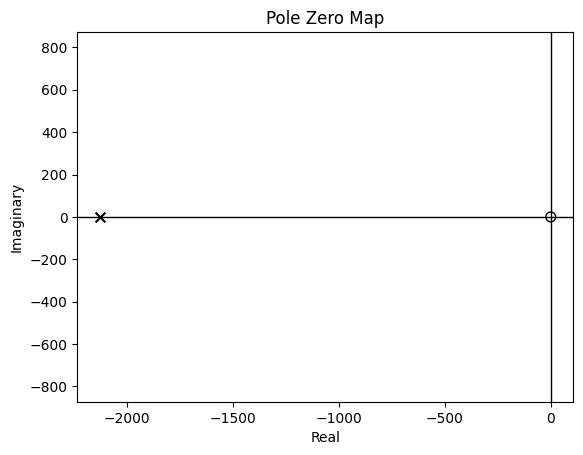

In [307]:
sys = sympy_to_tf(H_hp, 10e3, 47e-9)
ct.pzmap(sys)

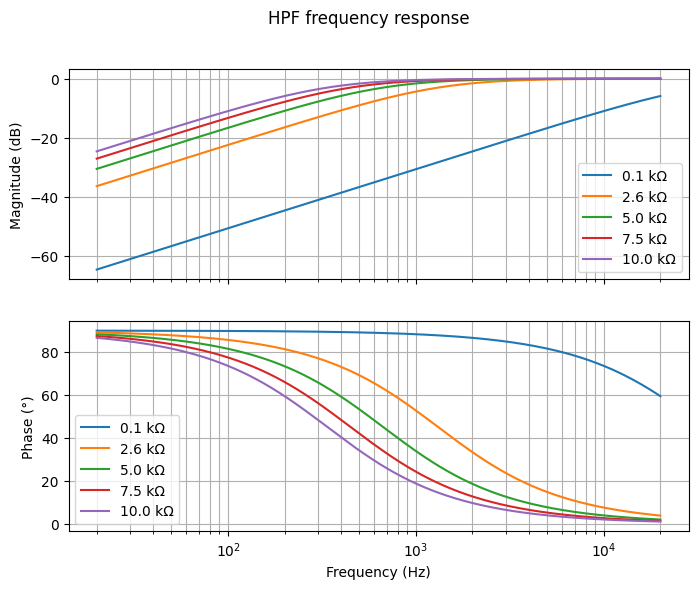

<Figure size 640x480 with 0 Axes>

In [308]:
pot_range= np.linspace(100, 10e3, 5) # the potentiometer range in Ω
C_value = 47e-9 # Farad
Variable_resistance_bode(H_hp,pot_range, C_value, (20,20000), 1000, "HPF frequency response", save = True)

Looking at the bode plot we can clearly see that the circuit is indeed behaving as a high-pass filter. Now let's see what happens when we change the resistance value by turning the potentiometer.

## 3. Fixed low-pass filter analysis
Regarding the LPF, it has a very basic structure :  
  
![title](img/Fix_LPF.png)

In [309]:
H_lp = sp.simplify((Zc)/(Zc + Zr)) #Transfer function using voltage divider
H_lp

1/(C*R*s + 1)

In [310]:
N, D = sp.fraction(H_lp)
D

C*R*s + 1

In [311]:
zeros = sp.solve(N,s)
poles = sp.solve(D,s)
poles[0]

-1/(C*R)

In [312]:
zeros

[]

For the fixed LPF, we should chose which component values to use for it to have the desired behavior. So we will use the same method as for the variable HPF but here the idae is not to see how the potentiometer alters th filter but rather wich resistance value is the best ofr our filter.

Define the list of resistor value below : 

In [313]:
Resistor_market = [220, 470, 1e3, 8e3, 10e3, 50e3, 100e3, 500e3, 1e6]

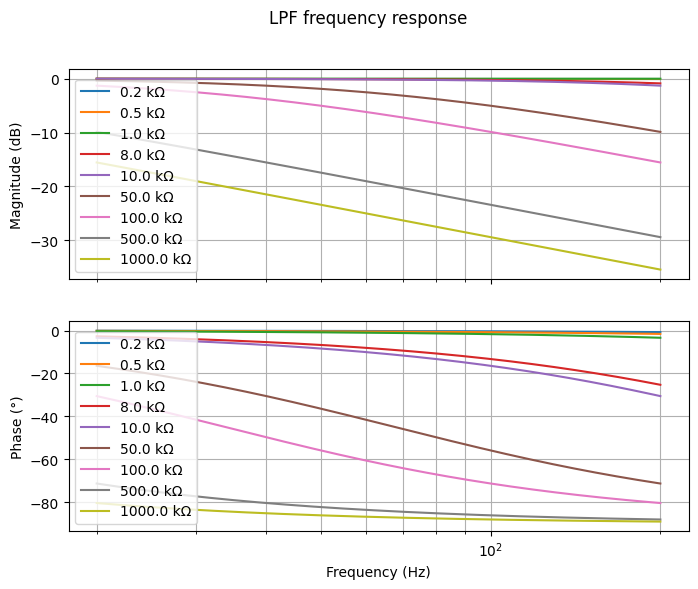

<Figure size 640x480 with 0 Axes>

In [314]:
Variable_resistance_bode(H_lp, Resistor_market, 47e-9,(20,200), 1000, "LPF frequency response", save = True)

## 4. Complete *Preshape* analysis
The *Preshape* is a combination of two filters that interacts with each other. We shall now study the global response of our circuit.  
  
![titl](img/Preshape.png)

### a. First Approximation
* Assuming negligible loading between both stages, the overall transfer function is approximated by the product of the individual transfer functions.  
  
Following this assumption, we can now use previous results to calculate the response of $H_{PreShape} = H_{hp}H_{lp}$

Let's define the symbols for the Preshape

In [315]:
R1, C1, R2, C2 = sp.symbols("R_1 C_1 R_2 C_2")

In [316]:
H_hp2 = H_hp.subs({
    R: R1,
    C: C1
})
H_lp2 = H_lp.subs({
    R: R2,
    C: C2
})
H_ps = H_hp2*H_lp2
#sp.expand(H_ps)
sp.expand(H_ps)

C_1*R_1*s/(C_1*C_2*R_1*R_2*s**2 + C_1*R_1*s + C_2*R_2*s + 1)

As expected this approximation of the PreShape gives us a second order transfer function. We can now look at its frequency response

In [317]:
Num, Den = sp.fraction(H_ps)
zeros = sp.solve(Num,s)
poles = sp.solve(Den,s)

In [318]:
zeros

[0]

In [319]:
poles

[-1/(C_1*R_1), -1/(C_2*R_2)]

To build the frequency response of the entire circuit we should first chose both capacitor's capacity and the LPF resistor's value.

In [320]:
def sympy_to_tf(H, r : float, c :float, R, C):
    """
    This function converts sympy equation with numerical coef to ct transfer function

    Parameters:
        H : sympy object
        r : float resistance value
        c : float capacity value

    Returns:
        sys : ct transfer function
    """
    values = {
    R: r,
    C: c
    }

    H_num = sp.simplify(H.subs(values))
    num, den = sp.fraction(H_num)
    N_poly = sp.Poly(num, s)
    D_poly = sp.Poly(den, s)
    N_coeffs = N_poly.all_coeffs()
    D_coeffs = D_poly.all_coeffs()
    N_coeffs = [float(c) for c in N_coeffs]
    D_coeffs = [float(c) for c in D_coeffs]
    sys = ct.TransferFunction(
        N_coeffs,
        D_coeffs
    )
    return sys

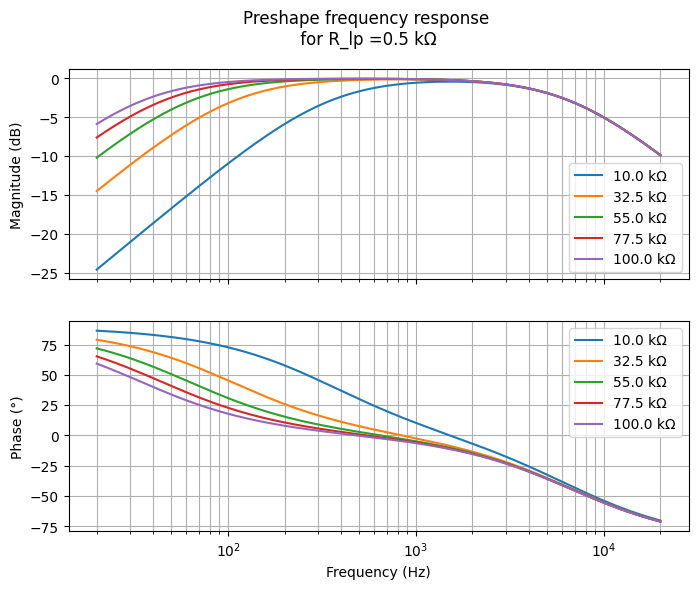

In [321]:
f = np.logspace(np.log10(20), np.log10(20000), 1000)
omega_range = 2*np.pi*f 

fig, (ax1, ax2) = plt.subplots(
2, 1,
sharex=True,
figsize=(8,6)
)

R_lp = 500        # LPF resistor's value
C_lp = 47e-9         # LPF capacitor's capacity
Lpf = sympy_to_tf(H_lp2, R_lp, C_lp, R2, C2)

R_values = np.linspace(10e3,100e3,5) # Potentiometer's values
for R_value in R_values:

    Hpf = sympy_to_tf(H_hp2, R_value, C_value, R1, C1)
    Pshape = Hpf*Lpf
    mag, phase, omega = ct.frequency_response(Pshape, omega_range)
    f = omega / (2*np.pi)
    mag_db = 20*np.log10(mag)
    phase_deg = np.degrees(phase)

    ax1.semilogx(f, mag_db, label=f"{R_value/1000:.1f} kΩ")
    ax2.semilogx(f, phase_deg, label=f"{R_value/1000:.1f} kΩ")

# Display settings for a clean view   
ax1.grid(True, which="both")
ax2.grid(True, which="both")
ax1.set_ylabel("Magnitude (dB)")
ax2.set_ylabel("Phase (°)")
ax2.set_xlabel("Frequency (Hz)")
ax1.legend()
ax2.legend()
title = f"Preshape frequency response \n for R_lp ={R_lp/1000:.1f} kΩ "
fig.suptitle(title)
# plt.savefig(f"plots/[BETTER]{title}.png")
plt.show()

### b. More accurate simulation

Let's reminds ourselves what was th objectives of the Preshape :
* Cut off some high-end to smoothen the signal, remove this high-end harshness
* Provide a control to change how much low-end are sent to the main effect circuit

The previous analysis assumed that the high-pass and low-pass stages were independent, allowing the overall transfer function to be approximated by the product of the individual transfer functions. This assumption neglects the loading effect between both passive RC networks.  
  
$H_{PreShape}(s) = H_{hp}(s)H_{lp}(s)$

In [322]:
H_ps

C_1*R_1*s/((C_1*R_1*s + 1)*(C_2*R_2*s + 1))

So let's apply Kirchoff's laws to solve for $V_{out}$ in order to have :  
* $H = \frac{V_{out}}{V_{in}}$

1. HPF node to LPF

$I_{in} - I_{pot} - I_{lp} = 0$

2. LPF node to out

$I_{lp} - I_{c} - I_{out} = 0$

In [323]:
Vin, V1, Vout, C_2 = sp.symbols("V_in V_1 V_out C_2")
Zc1 = Zc.subs({C : C1})
Zc2 = Zc.subs({C : C2})

Ic1 = (Vin - V1) / Zc1
Ir1 = V1 / R1

Ir2 = (V1 - Vout) / R2
Ic2 = Vout / Zc2

In [324]:
eq1 = Ic1 - Ir1 - Ir2
eq2 = Ir2 - Ic2

In [325]:
solutions = sp.solve([eq1,eq2], (V1, Vout))

In [326]:
solutions[Vout]

C_1*R_1*V_in*s/(C_1*C_2*R_1*R_2*s**2 + C_1*R_1*s + C_2*R_1*s + C_2*R_2*s + 1)

In [327]:
solutions[V1]

(C_1*C_2*R_1*R_2*V_in*s**2 + C_1*R_1*V_in*s)/(C_1*C_2*R_1*R_2*s**2 + C_1*R_1*s + C_2*R_1*s + C_2*R_2*s + 1)

In [328]:
H_accurate = (solutions[Vout])/(Vin)
H_accurate

C_1*R_1*s/(C_1*C_2*R_1*R_2*s**2 + C_1*R_1*s + C_2*R_1*s + C_2*R_2*s + 1)

The approximated Preshape transfer function : 

In [329]:
H_ps

C_1*R_1*s/((C_1*R_1*s + 1)*(C_2*R_2*s + 1))

And the more accurate one : 

In [330]:
H_accurate

C_1*R_1*s/(C_1*C_2*R_1*R_2*s**2 + C_1*R_1*s + C_2*R_1*s + C_2*R_2*s + 1)

#### Comparaison

Now let's try to compare both transfer functions to see the influence of the loading between the two stages.

In [331]:
sp.expand(H_ps)

C_1*R_1*s/(C_1*C_2*R_1*R_2*s**2 + C_1*R_1*s + C_2*R_2*s + 1)

In [332]:
sp.expand(H_accurate)

C_1*R_1*s/(C_1*C_2*R_1*R_2*s**2 + C_1*R_1*s + C_2*R_1*s + C_2*R_2*s + 1)

In [333]:
#sp.cancel(sp.factor(sp.together(H_ps/H_accurate)))
num, den = sp.fraction(H_ps/H_accurate)
sp.expand(num) - sp.expand(den)

C_2*R_1*s

$C_2 R_1 s$ is the only difference between the two modelisations. It is the consequence of the loading : basically C

The exact nodal analysis reveals an additional first-order term $R_1C_2$, originating from the interaction between the two passive stages. However, for the component values used in the circuit, this additional term has only a negligible influence on the overall frequency response, validating the simplified cascade approximation.

#### Bode and error

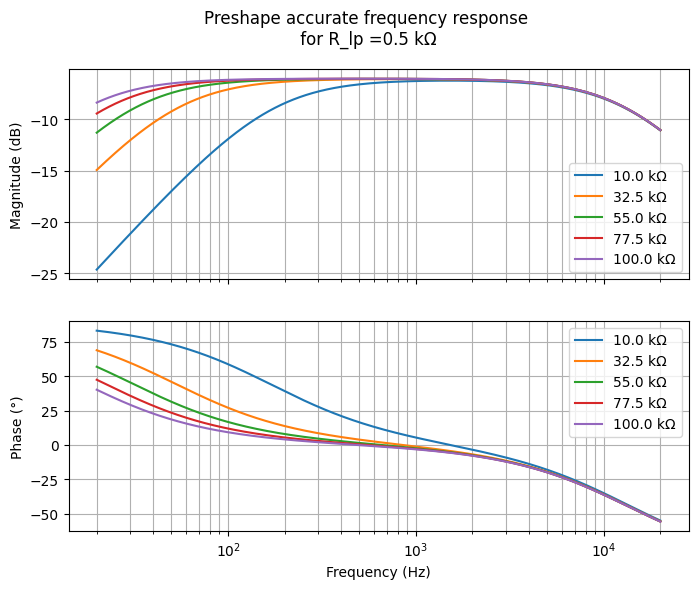

In [334]:
f = np.logspace(np.log10(20), np.log10(20000), 1000)
omega_range = 2*np.pi*f 

fig, (ax1, ax2) = plt.subplots(
2, 1,
sharex=True,
figsize=(8,6)
)

R_lp = 500        # LPF resistor's value
C_lp = 47e-9         # LPF capacitor's capacity

R_values = np.linspace(10e3,100e3,5) # Potentiometer's values
for R_value in R_values:

    values = {
    R1: R_value,
    C1: C_value,
    R2 : R_lp,
    C2 : C_lp
    }

    H_num = sp.simplify(H_accurate.subs(values))
    num, den = sp.fraction(H_num)
    N_poly = sp.Poly(num, s)
    D_poly = sp.Poly(den, s)
    N_coeffs = N_poly.all_coeffs()
    D_coeffs = D_poly.all_coeffs()
    N_coeffs = [float(c) for c in N_coeffs]
    D_coeffs = [float(c) for c in D_coeffs]
    Preshape = ct.TransferFunction(
        N_coeffs,
        D_coeffs
    )
    mag, phase, omega = ct.frequency_response(Preshape, omega_range)
    f = omega / (2*np.pi)
    mag_db = 20*np.log10(mag)
    phase_deg = np.degrees(phase)

    ax1.semilogx(f, mag_db, label=f"{R_value/1000:.1f} kΩ")
    ax2.semilogx(f, phase_deg, label=f"{R_value/1000:.1f} kΩ")

# Display settings for a clean view   
ax1.grid(True, which="both")
ax2.grid(True, which="both")
ax1.set_ylabel("Magnitude (dB)")
ax2.set_ylabel("Phase (°)")
ax2.set_xlabel("Frequency (Hz)")
ax1.legend()
ax2.legend()
title = f"Preshape accurate frequency response \n for R_lp ={R_lp/1000:.1f} kΩ "
fig.suptitle(title)
#plt.savefig(f"plots/[Accurate]{title}.png")
plt.show()

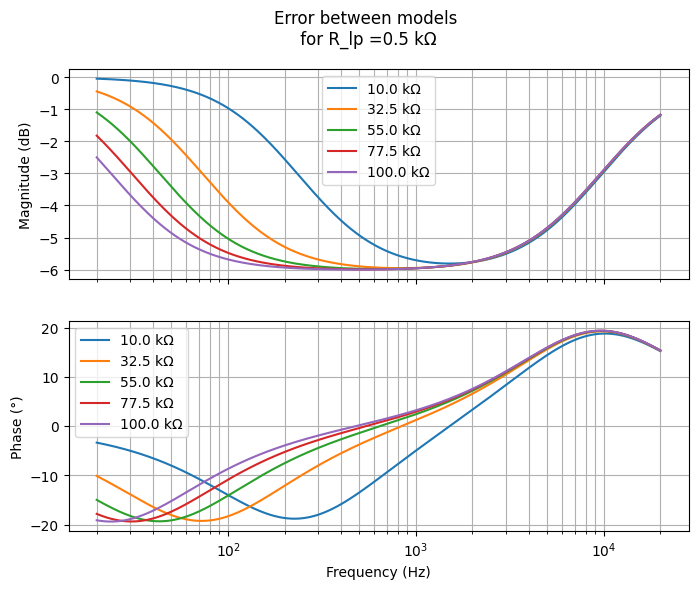

In [335]:
f = np.logspace(np.log10(20), np.log10(20000), 1000)
omega_range = 2*np.pi*f 

fig, (ax1, ax2) = plt.subplots(
2, 1,
sharex=True,
figsize=(8,6)
)

R_lp = 500        # LPF resistor's value
C_lp = 47e-9         # LPF capacitor's capacity

R_values = np.linspace(10e3,100e3,5) # Potentiometer's values
for R_value in R_values:

    values = {
    R1: R_value,
    C1: C_value,
    R2 : R_lp,
    C2 : C_lp
    }

    H_num = sp.simplify((H_accurate/H_ps).subs(values))
    num, den = sp.fraction(H_num)
    N_poly = sp.Poly(num, s)
    D_poly = sp.Poly(den, s)
    N_coeffs = N_poly.all_coeffs()
    D_coeffs = D_poly.all_coeffs()
    N_coeffs = [float(c) for c in N_coeffs]
    D_coeffs = [float(c) for c in D_coeffs]
    Preshape = ct.TransferFunction(
        N_coeffs,
        D_coeffs
    )
    mag, phase, omega = ct.frequency_response(Preshape, omega_range)
    f = omega / (2*np.pi)
    mag_db = 20*np.log10(mag)
    phase_deg = np.degrees(phase)

    ax1.semilogx(f, mag_db, label=f"{R_value/1000:.1f} kΩ")
    ax2.semilogx(f, phase_deg, label=f"{R_value/1000:.1f} kΩ")

# Display settings for a clean view   
ax1.grid(True, which="both")
ax2.grid(True, which="both")
ax1.set_ylabel("Magnitude (dB)")
ax2.set_ylabel("Phase (°)")
ax2.set_xlabel("Frequency (Hz)")
ax1.legend()
ax2.legend()
title = f"Error between models \n for R_lp ={R_lp/1000:.1f} kΩ "
fig.suptitle(title)
#plt.savefig(f"plots/[comparison]{title}.png")
plt.show()

# **VI. Design Discussion**